In [1]:
import sys, os
# add repo root to path so `sqw` and `applications` import when running from notebooks/
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from applications import community_detection as cd
from sqw.optimizer import build_parameterized_operator, optimize_angles

In [3]:
G = nx.Graph(nx.karate_club_graph().edges())   # unweighted
print('nodes:', G.number_of_nodes(), 'edges:', G.number_of_edges())
print('connected:', nx.is_connected(G))

nodes: 34 edges: 78
connected: True


In [4]:
V_max = cd.vertices_of_max_degree(G)
print('seed vertices (max degree):', V_max)

result = cd.detect_communities(G, V_max, max_steps=5000, verbose=False)
print('converged:', result['converged'], 'at step', result['steps_run'])
print('modularity:', round(cd.modularity(G, result['communities']), 4))
for rep, members in result['communities'].items():
    if len(members) > 1:
        print(f'  community {rep}: {members}')

seed vertices (max degree): [33]
converged: True at step 731
modularity: 0.3525
  community 33: [14, 15, 18, 2, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 8, 9]
  community 0: [0, 1, 10, 12, 13, 16, 17, 19, 21, 3, 4, 5, 6, 7]


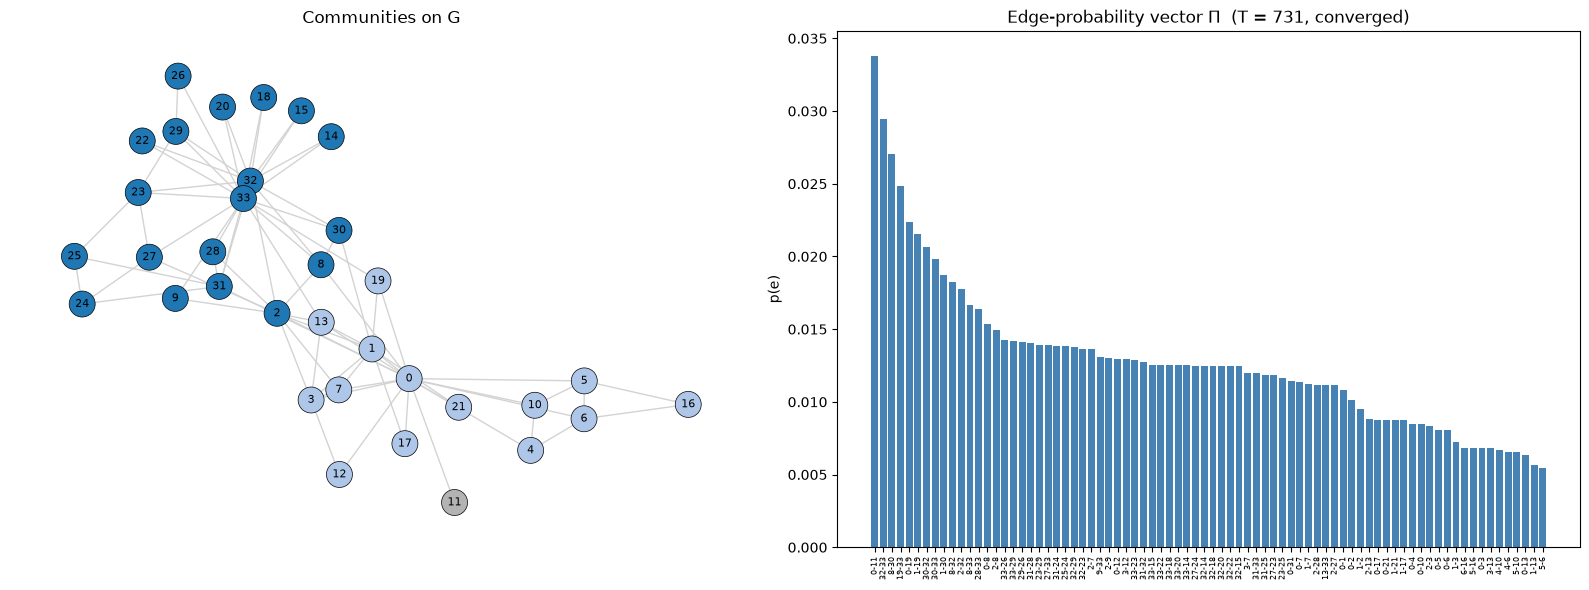

In [5]:
cd.visualize_communities(G, result, show_edge_probs=True)

In [6]:
def detect_with_angles(theta1, theta2, max_steps=1500):
    """Run community detection with a parameterized walk operator."""
    W = build_parameterized_operator(G, theta1, theta2)
    wr = cd.create_walk_operator(G)   # clique_map / node_index / G / dim
    wr['W'] = W                        # swap in the parameterized operator
    run = cd.run_walk(wr, V_max, max_steps=max_steps, min_steps=50)
    comms = cd.procedure(G, run['Pi'], run['edge_index'],
                         q=1.0 / G.number_of_edges())
    return comms

def neg_modularity(theta1, theta2):
    return -cd.modularity(G, detect_with_angles(theta1, theta2))

base = -neg_modularity(np.pi, np.pi)
print('baseline modularity at (pi, pi):', round(base, 4))

baseline modularity at (pi, pi): 0.2036


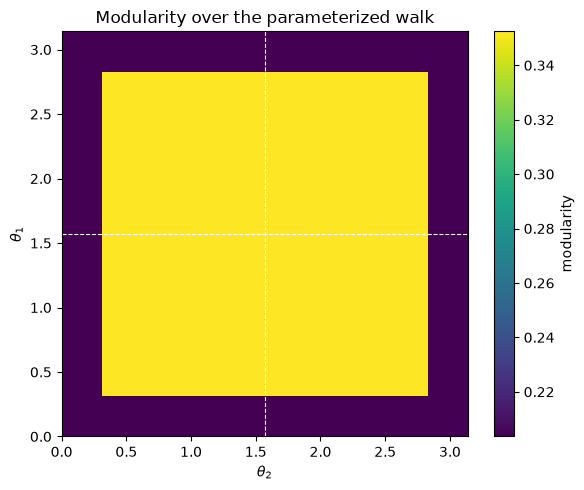

best on grid: theta1=0.349 theta2=0.349  modularity=0.3525


In [8]:
n = 10
grid = np.linspace(0, np.pi, n)
M = np.zeros((n, n))
for i, t1 in enumerate(grid):
    for j, t2 in enumerate(grid):
        M[i, j] = -neg_modularity(t1, t2)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(M, origin='lower', aspect='auto',
               extent=[grid[0], grid[-1], grid[0], grid[-1]], cmap='viridis')
ax.set_xlabel(r'$\theta_2$'); ax.set_ylabel(r'$\theta_1$')
ax.set_title('Modularity over the parameterized walk')
ax.axhline(0.5*np.pi, color='w', ls='--', lw=0.8)
ax.axvline(0.5*np.pi, color='w', ls='--', lw=0.8)
plt.colorbar(im, label='modularity'); plt.tight_layout(); plt.show()

bi, bj = np.unravel_index(np.argmax(M), M.shape)
print('best on grid: theta1=%.3f theta2=%.3f  modularity=%.4f'
      % (grid[bi], grid[bj], M[bi, bj]))

In [10]:
res = optimize_angles(neg_modularity, x0=[np.pi/2, np.pi/2],
                      method='Nelder-Mead',
                      options={'maxiter': 40, 'xatol': 1e-2, 'fatol': 1e-3})
print('optimized theta1, theta2:', round(res['theta1'], 3), round(res['theta2'], 3))
print('optimized modularity:', round(-res['value'], 4))
print('function evaluations:', len(res['history']))

optimized theta1, theta2: 1.571 1.571
optimized modularity: 0.3525
function evaluations: 15
